In [1]:
import pandas as pd
data = r'C:\Users\MSI\ML-final-project\Academic-Predictor-machine-based-on-performance-\data\preprocessed\preprocessed_data(1).csv'
df = pd.read_csv(data)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   598 non-null    int64  
 1   Year                     598 non-null    float64
 2   STEM_Major               598 non-null    int64  
 3   Diet_Quality             598 non-null    int64  
 4   Internet_Quality         598 non-null    int64  
 5   Employment               598 non-null    int64  
 6   Stress_Level             598 non-null    float64
 7   AI_Tool_Usage            598 non-null    int64  
 8   GPA                      598 non-null    float64
 9   Performance_Tier         598 non-null    int64  
 10  Total_Productive_Hrs     598 non-null    float64
 11  Distraction_Hrs          598 non-null    float64
 12  Study_Distraction_Ratio  598 non-null    float64
 13  Wellbeing_Score          598 non-null    float64
 14  Available_Study_Time     598 non-null

In [3]:
df.head(20)

,Gender,Year,STEM_Major,Diet_Quality,Internet_Quality,Employment,Stress_Level,AI_Tool_Usage,GPA,Performance_Tier,...,Resource_Quality,Focus_Ratio,Stress_Wellbeing,AI_Engagement,Lifestyle_Index,Study_Consistency,Time_Efficiency,Digital_Balance,Academic_Momentum,Stress_Load
0,1,2.0,1,3,3,0,5.5,3,3.39,2,...,9,1.904762,0.500000,34.5,0.658730,1,0.615385,1.428571,11.5,13.0625
1,0,1.0,1,4,3,0,5.5,4,3.69,2,...,12,1.250000,0.458333,42.0,0.773810,3,0.923077,2.500000,31.5,10.3125
2,1,1.0,1,2,3,0,7.5,3,3.48,2,...,6,0.980392,1.071429,37.5,0.448413,4,0.705882,0.588235,25.0,38.4375
3,1,2.0,1,3,3,0,5.5,4,3.50,2,...,9,0.487805,1.000000,44.8,0.500000,6,0.923077,0.975610,33.6,24.0625
4,1,2.0,1,2,2,0,7.5,4,3.70,2,...,4,0.784314,1.250000,44.8,0.333333,6,1.411765,0.784314,33.6,46.8750
5,1,3.0,1,2,4,0,9.5,4,2.90,1,...,8,0.465116,1.461538,38.8,0.515873,6,1.142857,0.465116,29.1,81.9375
6,0,2.0,0,2,3,0,3.5,3,3.05,2,...,6,0.196078,0.411765,33.6,0.496032,9,0.666667,0.588235,33.6,21.8750
7,1,1.0,1,3,1,0,7.5,3,3.00,2,...,3,1.951220,0.789474,40.5,0.444444,3,0.352941,0.731707,13.5,30.9375
8,1,3.0,0,2,2,2,1.5,2,3.50,2,...,4,1.428571,0.107143,22.4,0.587302,6,3.600000,0.952381,33.6,3.5625
9,1,3.0,1,3,1,1,5.5,1,3.89,2,...,3,0.487805,1.222222,10.5,0.333333,2,0.000000,0.243902,21.0,22.6875


In [4]:
df.shape


(598, 28)

In [5]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X = df.drop(['GPA', 'Performance_Tier', 'Available_Study_Time'], axis=1)
Y = df['Performance_Tier']

# ❌ Remove: X_selected = SelectKBest(...).fit(X, Y)  ← leaks test data
# Just define it here, fit inside Cell 5 after split
X_selector = SelectKBest(score_func=mutual_info_classif, k=26)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y  # ← added stratify
)

# Fit selector ONLY on train
X_selected_train = X_selector.fit_transform(X_train, y_train)
X_selected_test = X_selector.transform(X_test)

print(X_train.columns[X_selector.get_support(indices=True)])

Index(['Gender', 'Year', 'STEM_Major', 'Diet_Quality', 'Internet_Quality',
       'Employment', 'Stress_Level', 'AI_Tool_Usage', 'Total_Productive_Hrs',
       'Distraction_Hrs', 'Study_Distraction_Ratio', 'Wellbeing_Score',
       'Active_Engagement_Score', 'Study_Quality', 'AI_Enhanced_Study',
       'Resource_Quality', 'Focus_Ratio', 'Stress_Wellbeing', 'AI_Engagement',
       'Lifestyle_Index', 'Study_Consistency', 'Time_Efficiency',
       'Digital_Balance', 'Academic_Momentum', 'Stress_Load'],
      dtype='str')


c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=26 is greater than n_features=25. All the features will be returned.
  warnings.warn(


In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_selected_train_bal, y_train_bal = smote.fit_resample(X_selected_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_bal).value_counts())

After SMOTE:
Performance_Tier
0    256
1    256
2    256
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
X_train_scaled = s.fit_transform(X_selected_train_bal)
X_test_scaled = s.transform(X_selected_test)
X_train_scaled

array([[-1.25813119,  0.90730839, -1.63579568, ..., -1.11142268,
        -0.0298374 , -0.36748911],
       [-1.25813119,  2.25556798,  0.71361274, ..., -0.62250725,
         0.93950084,  0.40051691],
       [ 0.92311248, -0.44095121,  0.71361274, ...,  0.49726678,
        -0.87563254, -0.71775127],
       ...,
       [ 0.82075074,  0.84403705,  0.71361274, ..., -0.13072384,
         0.6851735 ,  0.40066771],
       [ 0.92311248, -1.34327354, -0.85872813, ..., -0.21444629,
        -1.02228285,  0.95322418],
       [-0.2826026 , -1.04394014, -0.58505792, ..., -0.1357774 ,
        -0.41909018, -1.29981537]], shape=(768, 25))

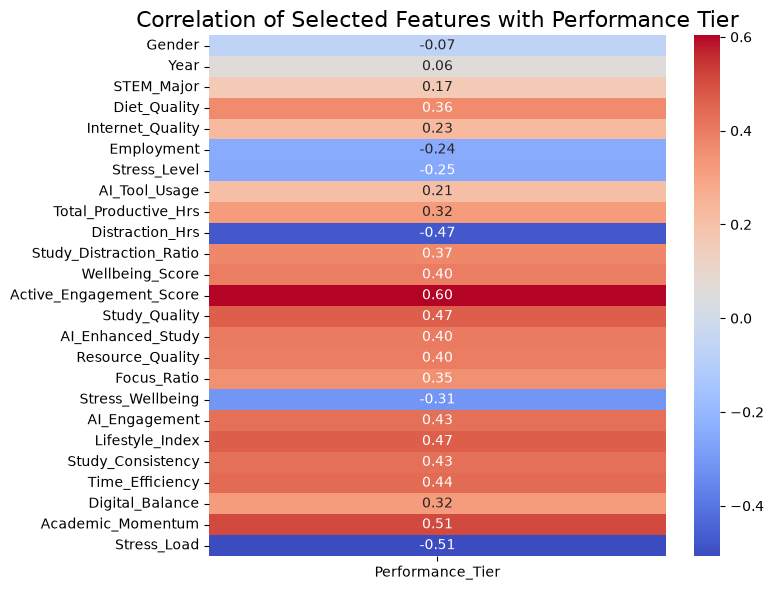

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# ✅ use X_selector (the SelectKBest object), not X_selected_train (the array)
selected_mask = X_selector.get_support()
selected_features = X_train.columns[selected_mask]

# Rebuild as DataFrame and add target
df_selected = pd.DataFrame(X_selected_train, columns=selected_features)
df_selected['Performance_Tier'] = y_train.values

# Plot correlation with Performance_Tier only
plt.figure(figsize=(8, 6))
corr = df_selected.corr()[['Performance_Tier']].drop('Performance_Tier')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Selected Features with Performance Tier', fontsize=16)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
models = {
    'lr': LogisticRegression(C=0.1, max_iter=500, solver='lbfgs'),
    'rf': RandomForestClassifier(max_depth=10, max_features='sqrt', min_samples_leaf=3, min_samples_split=5, n_estimators=300),
    'gb': GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200),
    'xgb': XGBClassifier(learning_rate=0.05, max_depth=5, n_estimators=300, subsample=0.8)
}


for name, model in models.items():
    model.fit(X_train_scaled, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    print(f"Model: {name}")
    print(accuracy_score(y_test, y_pred))
 

Model: lr
0.7333333333333333
Model: rf
0.7333333333333333
Model: gb
0.75
Model: xgb
0.7333333333333333


In [12]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [5, 8, 10],          
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train_bal)   # ✅ scaled
print("Best RF:", rf_grid.best_params_, rf_grid.best_score_)

lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'saga'], 'max_iter': [500, 1000]}
lr_grid = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42), lr_params, cv=5)
lr_grid.fit(X_train_scaled, y_train_bal)   # ✅ scaled
print("Best LR:", lr_grid.best_params_, lr_grid.best_score_)
gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_grid.fit(X_train_scaled, y_train_bal)  # ✅ scaled
print("Best GB:", gb_grid.best_params_, gb_grid.best_score_)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=5)
xgb_grid.fit(X_train_scaled, y_train_bal)  # ✅ scaled
print("Best XGB:", xgb_grid.best_params_, xgb_grid.best_score_)

Best RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 300} 0.8204227145403615


c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\s

Best LR: {'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'} 0.7161955691367456
Best GB: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200} 0.8400305576776164
Best XGB: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8} 0.8413632119514473
